**Import Libraries**

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import datetime as dt

In [ ]:

test_values = pd.read_csv('/content/Test Set Values.csv')
train_labels = pd.read_csv('/content/Training Set Labels.csv')
train_values = pd.read_csv('/content/Training Set values.csv')


print("Test Set Values Shape:", test_values.shape)
print("Training Set Labels Shape:", train_labels.shape)
print("Training Set Values Shape:", train_values.shape)

print("\n--- Training Set Values (First 5 rows) ---")
print(train_values.head())


print("\n--- Training Set Labels (First 5 rows) ---")
print(train_labels.head())

Test Set Values Shape: (14850, 40)
Training Set Labels Shape: (59400, 2)
Training Set Values Shape: (59400, 40)

--- Training Set Values (First 5 rows) ---
      id  amount_tsh date_recorded        funder  gps_height     installer  \
0  69572      6000.0    2011-03-14         Roman        1390         Roman   
1   8776         0.0    2013-03-06       Grumeti        1399       GRUMETI   
2  34310        25.0    2013-02-25  Lottery Club         686  World vision   
3  67743         0.0    2013-01-28        Unicef         263        UNICEF   
4  19728         0.0    2011-07-13   Action In A           0       Artisan   

   longitude   latitude              wpt_name  num_private  ... payment_type  \
0  34.938093  -9.856322                  none            0  ...     annually   
1  34.698766  -2.147466              Zahanati            0  ...    never pay   
2  37.460664  -3.821329           Kwa Mahundi            0  ...   per bucket   
3  38.486161 -11.155298  Zahanati Ya Nanyumbu          

**Merging Training Dataset**

In [ ]:
train_df = pd.merge(train_values, train_labels, on='id')

print(train_df.head())

      id  amount_tsh date_recorded        funder  gps_height     installer  \
0  69572      6000.0    2011-03-14         Roman        1390         Roman   
1   8776         0.0    2013-03-06       Grumeti        1399       GRUMETI   
2  34310        25.0    2013-02-25  Lottery Club         686  World vision   
3  67743         0.0    2013-01-28        Unicef         263        UNICEF   
4  19728         0.0    2011-07-13   Action In A           0       Artisan   

   longitude   latitude              wpt_name  num_private  ... water_quality  \
0  34.938093  -9.856322                  none            0  ...          soft   
1  34.698766  -2.147466              Zahanati            0  ...          soft   
2  37.460664  -3.821329           Kwa Mahundi            0  ...          soft   
3  38.486161 -11.155298  Zahanati Ya Nanyumbu            0  ...          soft   
4  31.130847  -1.825359               Shuleni            0  ...          soft   

  quality_group      quantity  quantity_grou

In [ ]:
train_df.shape

(59400, 41)

In [ ]:
train_df.head(5)

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,...,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,...,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,...,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,...,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,functional
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,...,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe,non functional
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,...,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional


In [ ]:
train_df.describe()

,id,amount_tsh,gps_height,longitude,latitude,num_private,region_code,district_code,population,construction_year
count,59400.000000,59400.000000,59400.000000,59400.000000,5.940000e+04,59400.000000,59400.000000,59400.000000,59400.000000,59400.000000
mean,37115.131768,317.650385,668.297239,34.077427,-5.706033e+00,0.474141,15.297003,5.629747,179.909983,1300.652475
std,21453.128371,2997.574558,693.116350,6.567432,2.946019e+00,12.236230,17.587406,9.633649,471.482176,951.620547
min,0.000000,0.000000,-90.000000,0.000000,-1.164944e+01,0.000000,1.000000,0.000000,0.000000,0.000000
25%,18519.750000,0.000000,0.000000,33.090347,-8.540621e+00,0.000000,5.000000,2.000000,0.000000,0.000000
50%,37061.500000,0.000000,369.000000,34.908743,-5.021597e+00,0.000000,12.000000,3.000000,25.000000,1986.000000
75%,55656.500000,20.000000,1319.250000,37.178387,-3.326156e+00,0.000000,17.000000,5.000000,215.000000,2004.000000
max,74247.000000,350000.000000,2770.000000,40.345193,-2.000000e-08,1776.000000,99.000000,80.000000,30500.000000,2013.000000


**Understanding the Data**

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59400 entries, 0 to 59399
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     59400 non-null  int64  
 1   amount_tsh             59400 non-null  float64
 2   date_recorded          59400 non-null  object 
 3   funder                 55763 non-null  object 
 4   gps_height             59400 non-null  int64  
 5   installer              55745 non-null  object 
 6   longitude              59400 non-null  float64
 7   latitude               59400 non-null  float64
 8   wpt_name               59398 non-null  object 
 9   num_private            59400 non-null  int64  
 10  basin                  59400 non-null  object 
 11  subvillage             59029 non-null  object 
 12  region                 59400 non-null  object 
 13  region_code            59400 non-null  int64  
 14  district_code          59400 non-null  int64  
 15  lg

In [ ]:
train_df.nunique().sort_values(ascending=False)

,0
id,59400
latitude,57517
longitude,57516
wpt_name,37399
subvillage,19287
scheme_name,2695
gps_height,2428
installer,2145
ward,2092
funder,1896


In [ ]:

pd.set_option('display.max_columns', None)


pd.set_option('display.max_colwidth', None)

train_df.head(5)

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,basin,subvillage,region,region_code,district_code,lga,ward,population,public_meeting,recorded_by,scheme_management,scheme_name,permit,construction_year,extraction_type,extraction_type_group,extraction_type_class,management,management_group,payment,payment_type,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,Lake Nyasa,Mnyusi B,Iringa,11,5,Ludewa,Mundindi,109,True,GeoData Consultants Ltd,VWC,Roman,False,1999,gravity,gravity,gravity,vwc,user-group,pay annually,annually,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,Lake Victoria,Nyamara,Mara,20,2,Serengeti,Natta,280,NaN,GeoData Consultants Ltd,Other,NaN,True,2010,gravity,gravity,gravity,wug,user-group,never pay,never pay,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,Pangani,Majengo,Manyara,21,4,Simanjiro,Ngorika,250,True,GeoData Consultants Ltd,VWC,Nyumba ya mungu pipe scheme,True,2009,gravity,gravity,gravity,vwc,user-group,pay per bucket,per bucket,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,functional
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,Ruvuma / Southern Coast,Mahakamani,Mtwara,90,63,Nanyumbu,Nanyumbu,58,True,GeoData Consultants Ltd,VWC,NaN,True,1986,submersible,submersible,submersible,vwc,user-group,never pay,never pay,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe,non functional
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,Lake Victoria,Kyanyamisa,Kagera,18,1,Karagwe,Nyakasimbi,0,True,GeoData Consultants Ltd,NaN,NaN,True,0,gravity,gravity,gravity,other,other,never pay,never pay,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional


In [ ]:
train_df.describe(include=['object'])

,date_recorded,funder,installer,wpt_name,basin,subvillage,region,lga,ward,public_meeting,recorded_by,scheme_management,scheme_name,permit,extraction_type,extraction_type_group,extraction_type_class,management,management_group,payment,payment_type,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
count,59400,55763,55745,59398,59400,59029,59400,59400,59400,56066,59400,55522,30590,56344,59400,59400,59400,59400,59400,59400,59400,59400,59400,59400,59400,59400,59400,59400,59400,59400,59400
unique,356,1896,2145,37399,9,19287,21,125,2092,2,1,11,2695,2,18,13,7,12,5,7,7,8,6,5,5,10,7,3,7,6,3
top,2011-03-15,Government Of Tanzania,DWE,none,Lake Victoria,Madukani,Iringa,Njombe,Igosi,True,GeoData Consultants Ltd,VWC,K,True,gravity,gravity,gravity,vwc,user-group,never pay,never pay,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
freq,572,9084,17402,3563,10248,508,5294,2503,307,51011,59400,36793,682,38852,26780,26780,26780,40507,52490,25348,25348,50818,50818,33186,33186,17021,17021,45794,28522,34625,32259


**Missing Values**

**Check percentage of missing values per column**

In [ ]:

missing_data = train_df.isnull().sum() / len(train_df) * 100
print(missing_data[missing_data > 0].sort_values(ascending=False))

scheme_name              48.560013
scheme_management         6.607543
installer                 6.078662
funder                    6.037091
public_meeting            5.612139
permit                    5.067092
subvillage                0.618952
wpt_name                  0.006929
num_private               0.002310
basin                     0.002310
lga                       0.002310
district_code             0.002310
region_code               0.002310
region                    0.002310
recorded_by               0.002310
population                0.002310
ward                      0.002310
construction_year         0.002310
extraction_type           0.002310
extraction_type_group     0.002310
extraction_type_class     0.002310
management                0.002310
management_group          0.002310
payment                   0.002310
payment_type              0.002310
water_quality             0.002310
quality_group             0.002310
quantity                  0.002310
quantity_group      

In [ ]:
train_df

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,...,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,...,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,...,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,...,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,functional
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,...,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe,non functional
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,...,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59395,60739,10.0,2013-05-03,Germany Republi,1210,CES,37.169807,-3.253847,Area Three Namba 27,0,...,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
59396,27263,4700.0,2011-05-07,Cefa-njombe,1212,Cefa,35.249991,-9.070629,Kwa Yahona Kuvala,0,...,soft,good,enough,enough,river,river/lake,surface,communal standpipe,communal standpipe,functional
59397,37057,0.0,2011-04-11,NaN,0,NaN,34.017087,-8.750434,Mashine,0,...,fluoride,fluoride,enough,enough,machine dbh,borehole,groundwater,hand pump,hand pump,functional
59398,31282,0.0,2011-03-08,Malec,0,Musa,35.861315,-6.378573,Mshoro,0,...,soft,good,insufficient,insufficient,shallow well,shallow well,groundwater,hand pump,hand pump,functional


**Check for zeros in columns where zero doesn't make sense**

In [ ]:

cols_to_fix = ['construction_year', 'population', 'gps_height']
for col in cols_to_fix:
    zero_count = (train_df[col] == 0).sum()
    print(f"{col} has {zero_count} zeros")

construction_year has 20709 zeros
population has 21381 zeros
gps_height has 20438 zeros


In [ ]:

zeros_mask = (train_df['construction_year'] == 0) & (train_df['population'] == 0) & (train_df['gps_height'] == 0)

print(f"Rows where all three are zero: {zeros_mask.sum()}")


lon_zero = (train_df['longitude'] == 0).sum()
print(f"Rows with longitude as 0: {lon_zero}")


overlap = train_df[(train_df['construction_year'] == 0) & (train_df['longitude'] == 0)].shape[0]
print(f"Overlap between 0 construction_year and 0 longitude: {overlap}")


print("\nTop regions with 0 construction_year:")
print(train_df[train_df['construction_year'] == 0]['region'].value_counts().head())

Rows where all three are zero: 19668
Rows with longitude as 0: 1812
Overlap between 0 construction_year and 0 longitude: 1812

Top regions with 0 construction_year:
region
Shinyanga    4818
Mbeya        4639
Kagera       3316
Mwanza       2747
Dodoma       2201
Name: count, dtype: int64


**categorical columns**

In [ ]:

cat_cols = ['management', 'payment', 'water_quality', 'source', 'extraction_type']

for col in cat_cols:
    train_df[col] = train_df[col].fillna('unknown')

In [ ]:
cols_to_nan = ['construction_year', 'population', 'gps_height', 'longitude']
for col in cols_to_nan:
    train_df[col] = train_df[col].replace(0, np.nan)

In [ ]:

zeros_mask = (train_df['construction_year'] == 0) & (train_df['population'] == 0) & (train_df['gps_height'] == 0)

print(f"Rows where all three are zero: {zeros_mask.sum()}")


lon_zero = (train_df['longitude'] == 0).sum()
print(f"Rows with longitude as 0: {lon_zero}")


overlap = train_df[(train_df['construction_year'] == 0) & (train_df['longitude'] == 0)].shape[0]
print(f"Overlap between 0 construction_year and 0 longitude: {overlap}")


print("\nTop regions with 0 construction_year:")
print(train_df[train_df['construction_year'] == 0]['region'].value_counts().head())

Rows where all three are zero: 0
Rows with longitude as 0: 0
Overlap between 0 construction_year and 0 longitude: 0

Top regions with 0 construction_year:
Series([], Name: count, dtype: int64)


In [ ]:
train_df.columns

Index(['id', 'amount_tsh', 'date_recorded', 'funder', 'gps_height',
       'installer', 'longitude', 'latitude', 'wpt_name', 'num_private',
       'basin', 'subvillage', 'region', 'region_code', 'district_code', 'lga',
       'ward', 'population', 'public_meeting', 'recorded_by',
       'scheme_management', 'scheme_name', 'permit', 'construction_year',
       'extraction_type', 'extraction_type_group', 'extraction_type_class',
       'management', 'management_group', 'payment', 'payment_type',
       'water_quality', 'quality_group', 'quantity', 'quantity_group',
       'source', 'source_type', 'source_class', 'waterpoint_type',
       'waterpoint_type_group', 'status_group'],
      dtype='object')

Duplicate Columns

In [ ]:
train_df[['payment', 'payment_type']].value_counts()

,,count
payment,payment_type,
never pay,never pay,25348
pay per bucket,per bucket,8985
pay monthly,monthly,8300
unknown,unknown,8157
pay when scheme fails,on failure,3914
pay annually,annually,3642
other,other,1054


In [ ]:
train_df[['extraction_type','extraction_type_group','extraction_type_class']].value_counts()

,,,count
extraction_type,extraction_type_group,extraction_type_class,
gravity,gravity,gravity,26780
nira/tanira,nira/tanira,handpump,8154
other,other,other,6430
submersible,submersible,submersible,4764
swn 80,swn 80,handpump,3670
mono,mono,motorpump,2865
india mark ii,india mark ii,handpump,2400
afridev,afridev,handpump,1770
ksb,submersible,submersible,1415


In [ ]:
cols_to_drop = [
    'scheme_name',
    'payment',
    'extraction_type',
    'extraction_type_class',
    'quantity_group',
    'water_quality',
    'waterpoint_type',
    'source',
    'source_class',
    'management_group'
]

In [ ]:
final_df = train_df.drop(columns=cols_to_drop)

In [ ]:
final_df.shape

(59400, 31)

In [ ]:
train_df.shape

(59400, 41)

In [ ]:

pd.set_option('display.max_columns', None)

pd.set_option('display.max_colwidth', None)

final_df.head(5)

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,basin,subvillage,region,region_code,district_code,lga,ward,population,public_meeting,recorded_by,scheme_management,permit,construction_year,extraction_type_group,management,payment_type,quality_group,quantity,source_type,waterpoint_type_group,status_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,Lake Nyasa,Mnyusi B,Iringa,11,5,Ludewa,Mundindi,109,True,GeoData Consultants Ltd,VWC,False,1999,gravity,vwc,annually,good,enough,spring,communal standpipe,functional
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,Lake Victoria,Nyamara,Mara,20,2,Serengeti,Natta,280,NaN,GeoData Consultants Ltd,Other,True,2010,gravity,wug,never pay,good,insufficient,rainwater harvesting,communal standpipe,functional
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,Pangani,Majengo,Manyara,21,4,Simanjiro,Ngorika,250,True,GeoData Consultants Ltd,VWC,True,2009,gravity,vwc,per bucket,good,enough,dam,communal standpipe,functional
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,Ruvuma / Southern Coast,Mahakamani,Mtwara,90,63,Nanyumbu,Nanyumbu,58,True,GeoData Consultants Ltd,VWC,True,1986,submersible,vwc,never pay,good,dry,borehole,communal standpipe,non functional
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,Lake Victoria,Kyanyamisa,Kagera,18,1,Karagwe,Nyakasimbi,0,True,GeoData Consultants Ltd,NaN,True,0,gravity,other,never pay,good,seasonal,rainwater harvesting,communal standpipe,functional


In [ ]:
final_df.nunique().sort_values(ascending=False)

,0
id,59400
latitude,57517
longitude,57516
wpt_name,37399
subvillage,19287
gps_height,2428
installer,2145
ward,2092
funder,1896
population,1049


**Missing Percentage**

In [ ]:
missing_data = final_df.isnull().sum() / len(train_df) * 100
print(missing_data[missing_data > 0].sort_values(ascending=False))

scheme_management    6.528620
installer            6.153199
funder               6.122896
public_meeting       5.612795
permit               5.144781
subvillage           0.624579
wpt_name             0.003367
dtype: float64


**Water Quantity vs. Pump Reliability**

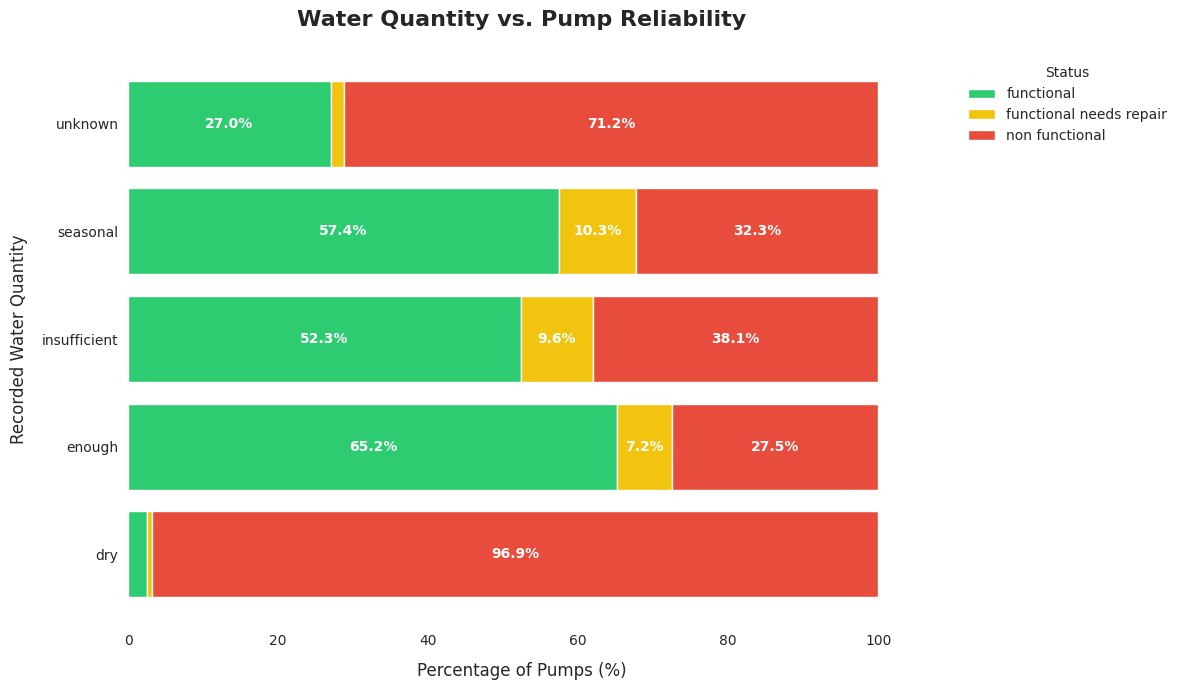

In [ ]:
quantity_props = pd.crosstab(train_df['quantity'],
                             train_df['status_group'],
                             normalize='index') * 100

sns.set_style("white")
plt.rcParams['font.family'] = 'sans-serif'


ax = quantity_props.plot(kind='barh',
                         stacked=True,
                         figsize=(12, 7),
                         color=['#2ECC71', '#F1C40F', '#E74C3C'],
                         width=0.8)


for p in ax.patches:
    width = p.get_width()
    if width > 5:
        ax.annotate(f'{width:.1f}%',
                    (p.get_x() + width / 2, p.get_y() + p.get_height() / 2),
                    ha='center', va='center',
                    color='white', fontweight='bold', fontsize=10)

plt.title('Water Quantity vs. Pump Reliability', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Percentage of Pumps (%)', fontsize=12, labelpad=10)
plt.ylabel('Recorded Water Quantity', fontsize=12, labelpad=10)
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

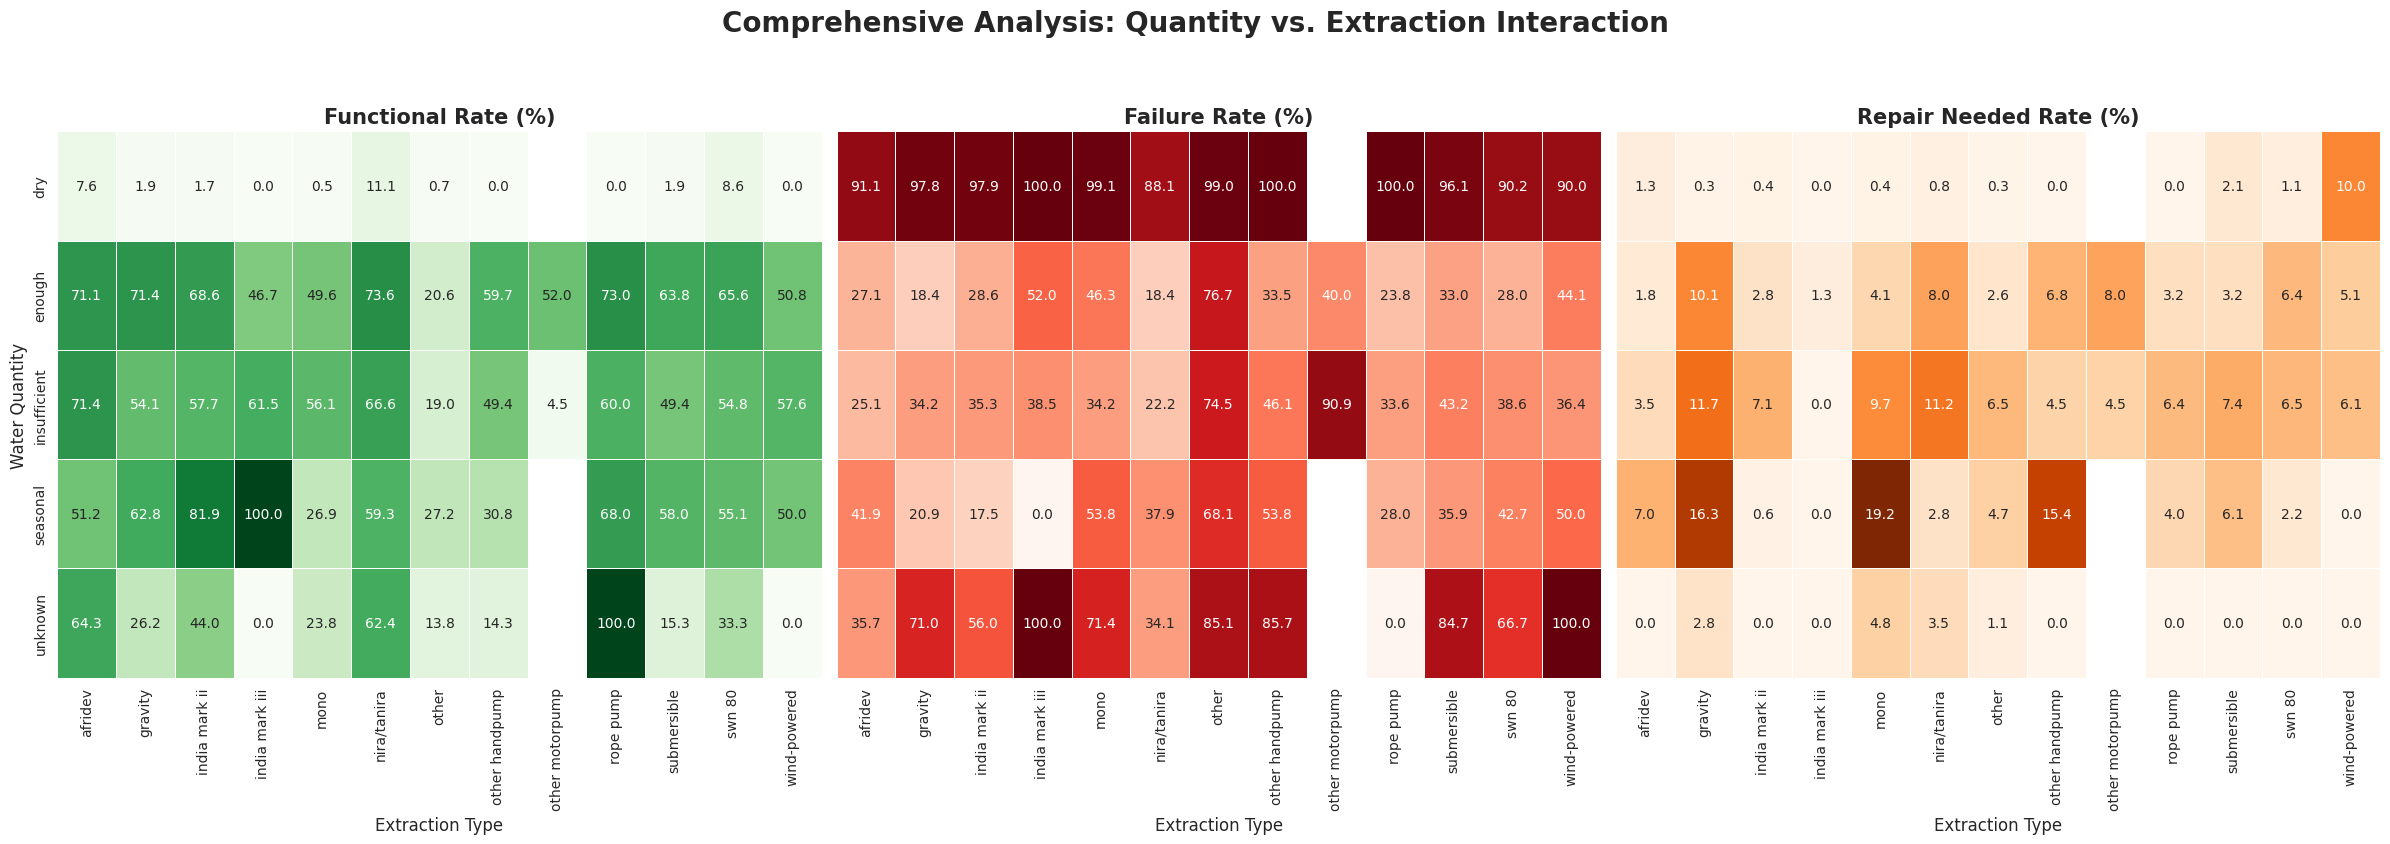

In [ ]:
statuses = ['functional', 'non functional', 'functional needs repair']
titles = ['Functional Rate (%)', 'Failure Rate (%)', 'Repair Needed Rate (%)']
cmaps = ['Greens', 'Reds', 'Oranges']

fig, axes = plt.subplots(1, 3, figsize=(24, 8), sharey=True)

for i, status in enumerate(statuses):

    pivot_df = train_df.groupby(['quantity', 'extraction_type_group'])['status_group'].apply(
        lambda x: (x == status).mean() * 100
    ).unstack()


    sns.heatmap(pivot_df, annot=True, fmt=".1f", cmap=cmaps[i],
                linewidths=0.5, ax=axes[i], cbar=False)

    axes[i].set_title(titles[i], fontsize=15, fontweight='bold')
    axes[i].set_xlabel('Extraction Type', fontsize=12)
    if i == 0:
        axes[i].set_ylabel('Water Quantity', fontsize=12)
    else:
        axes[i].set_ylabel('')

plt.suptitle('Comprehensive Analysis: Quantity vs. Extraction Interaction', fontsize=20, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

/tmp/ipykernel_5683/973093622.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=age_data, x='status_group', y='pump_age', palette='Set2')


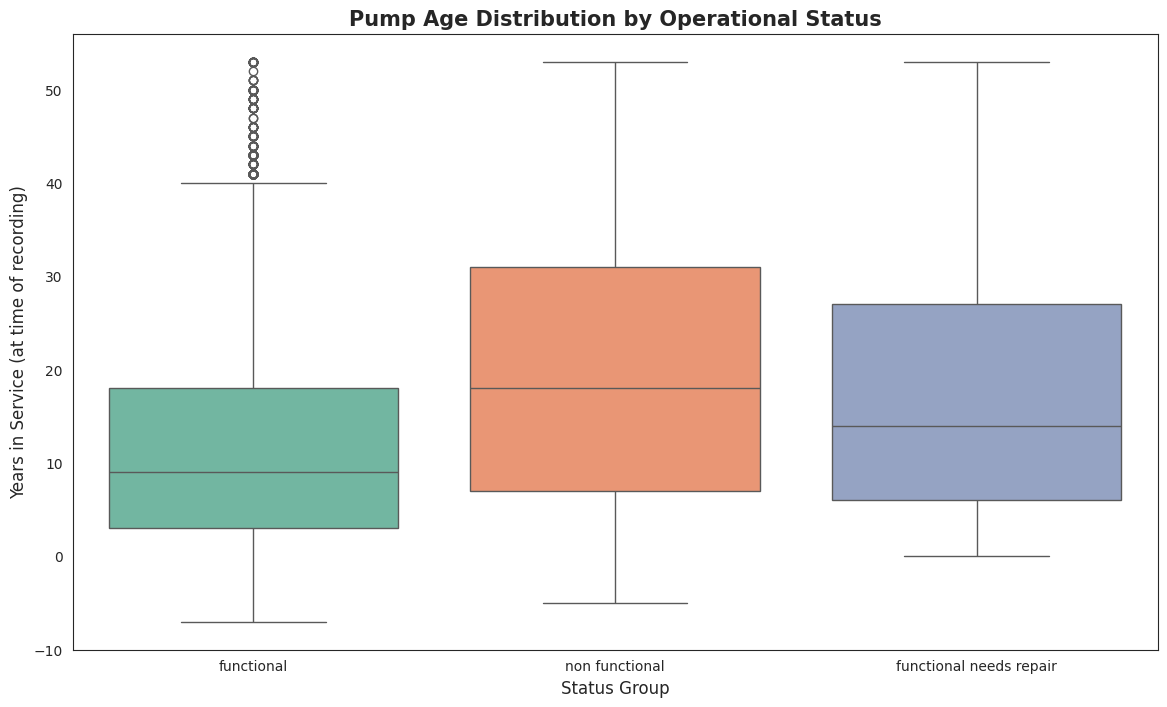

In [ ]:
train_df['date_recorded'] = pd.to_datetime(train_df['date_recorded'])
train_df['year_recorded'] = train_df['date_recorded'].dt.year


# Filtered out 0s because they are not real years
train_df['pump_age'] = train_df['year_recorded'] - train_df['construction_year']
age_data = train_df[train_df['construction_year'] > 0].copy()


plt.figure(figsize=(14, 8))
sns.boxplot(data=age_data, x='status_group', y='pump_age', palette='Set2')

plt.title('Pump Age Distribution by Operational Status', fontsize=15, fontweight='bold')
plt.ylabel('Years in Service (at time of recording)', fontsize=12)
plt.xlabel('Status Group', fontsize=12)
plt.show()

In [ ]:
final_df.columns

Index(['id', 'amount_tsh', 'date_recorded', 'funder', 'gps_height',
       'installer', 'longitude', 'latitude', 'wpt_name', 'num_private',
       'basin', 'subvillage', 'region', 'region_code', 'district_code', 'lga',
       'ward', 'population', 'public_meeting', 'recorded_by',
       'scheme_management', 'permit', 'construction_year',
       'extraction_type_group', 'management', 'payment_type', 'quality_group',
       'quantity', 'source_type', 'waterpoint_type_group', 'status_group'],
      dtype='object')

**STATUS GROUP DISTRIBUTION**

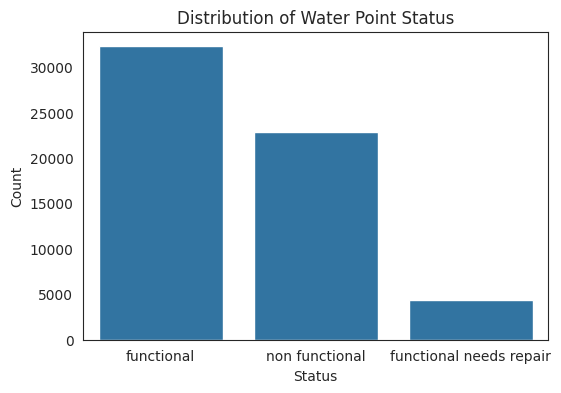

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=final_df, x='status_group', order=final_df['status_group'].value_counts().index)
plt.title("Distribution of Water Point Status")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

SOURCE TYPE vs STATUS

In [ ]:
final_df['status_group'] = final_df['status_group'].str.lower()


final_df['is_failed'] = final_df['status_group'].apply(
    lambda x: 1 if x == 'non functional' else 0
)


failure_rate = final_df.groupby('extraction_type_group')['is_failed'].mean()

failure_rate = failure_rate.sort_values(ascending=False)
failure_rate

,is_failed
extraction_type_group,
other,0.807932
mono,0.577312
india mark iii,0.540816
wind-powered,0.512821
other motorpump,0.491803
other handpump,0.472527
submersible,0.420295
swn 80,0.372752
india mark ii,0.363750


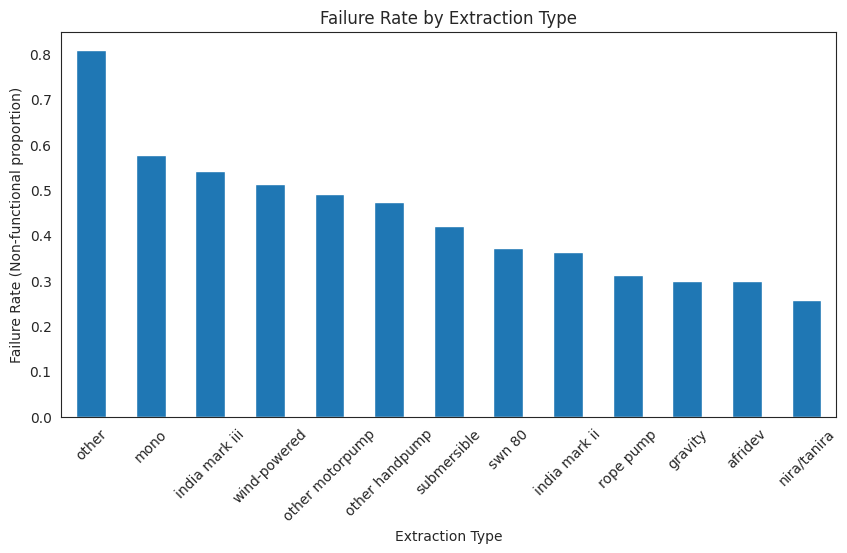

In [ ]:
plt.figure(figsize=(10,5))

failure_rate.plot(kind='bar')

plt.title("Failure Rate by Extraction Type")
plt.ylabel("Failure Rate (Non-functional proportion)")
plt.xlabel("Extraction Type")

plt.xticks(rotation=45)
plt.show()

**Regional Comparison of Pump Functionality**

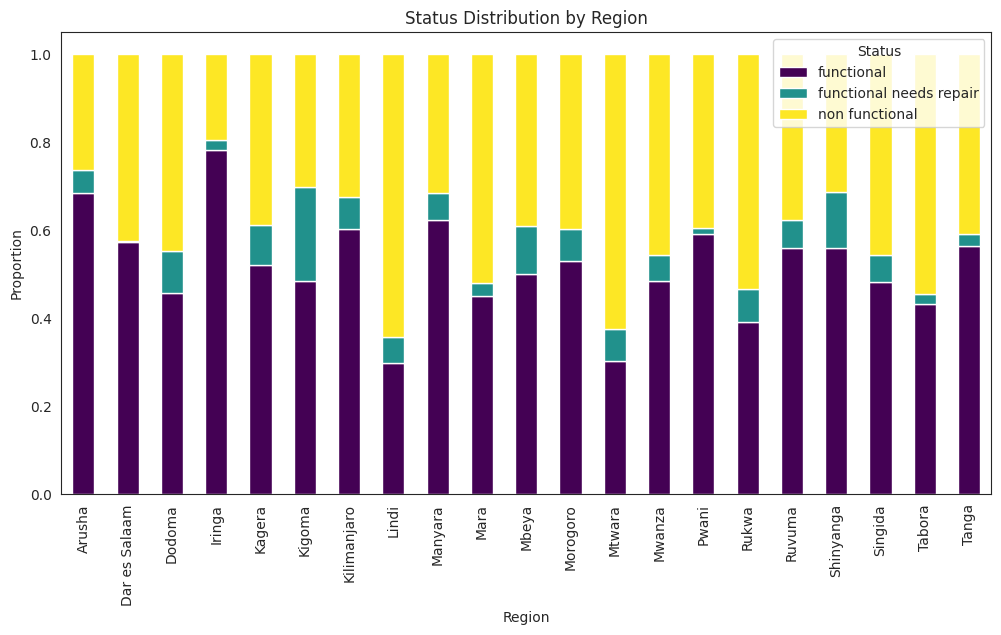

In [ ]:
region_status = pd.crosstab(
    final_df['region'],
    final_df['status_group'],
    normalize='index'
)

region_status.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6),
    colormap='viridis'
)

plt.title("Status Distribution by Region")
plt.ylabel("Proportion")
plt.xlabel("Region")
plt.legend(title="Status")
plt.show()

**Composition of Pump Status by Management**

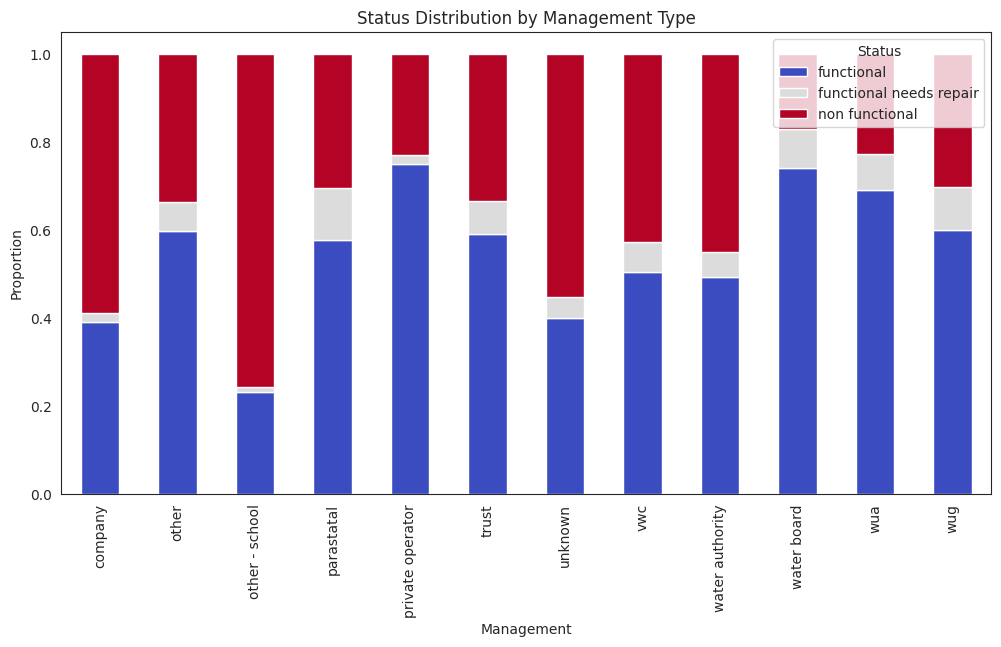

In [ ]:
mgmt_status = pd.crosstab(
    final_df['management'],
    final_df['status_group'],
    normalize='index'
)

mgmt_status.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6),
    colormap='coolwarm'
)

plt.title("Status Distribution by Management Type")
plt.ylabel("Proportion")
plt.xlabel("Management")
plt.legend(title="Status")
plt.show()

**Failure Probability by Extraction Technology**

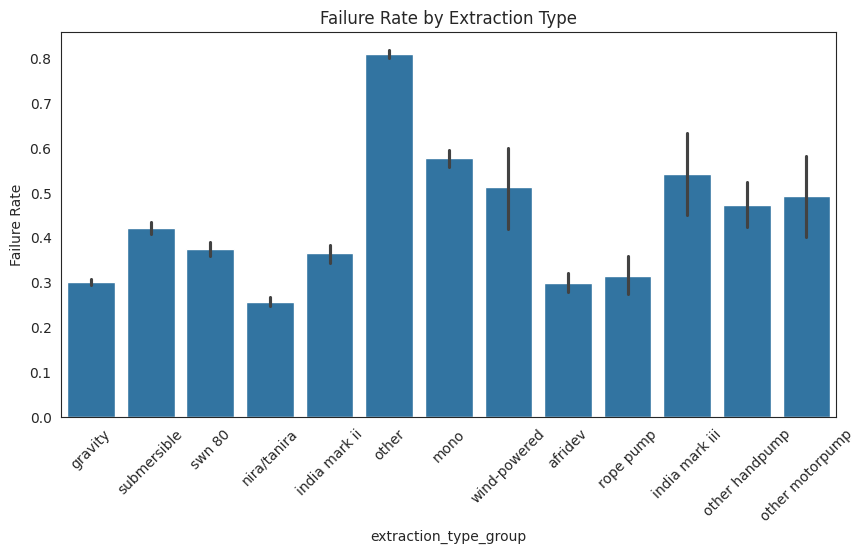

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

final_df['is_failed'] = final_df['status_group'].apply(
    lambda x: 1 if x == 'non functional' else 0
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=final_df,
    x='extraction_type_group',
    y='is_failed',
    estimator='mean'
)

plt.title("Failure Rate by Extraction Type")
plt.xticks(rotation=45)
plt.ylabel("Failure Rate")
plt.show()

**Impact of Population Density on Pump Status**

In [ ]:
final_df['is_failed'] = final_df['status_group'].apply(
    lambda x: 1 if x == 'non functional' else 0
)

combo_fail = final_df.groupby(
    ['management', 'payment_type']
)['is_failed'].mean().reset_index()

combo_fail = combo_fail.sort_values('is_failed', ascending=False)

combo_fail.head()

,management,payment_type,is_failed
38,unknown,other,1.000000
48,water authority,annually,0.933333
14,other - school,never pay,0.888889
50,water authority,never pay,0.746130
45,vwc,other,0.634146


In [ ]:
top10 = combo_fail.head(10)

top10

,management,payment_type,is_failed
38,unknown,other,1.000000
48,water authority,annually,0.933333
14,other - school,never pay,0.888889
50,water authority,never pay,0.746130
45,vwc,other,0.634146
1,company,monthly,0.630058
47,vwc,unknown,0.607839
36,unknown,never pay,0.607407
15,other - school,per bucket,0.604651
52,water authority,other,0.583333


In [ ]:
top_keys = list(zip(top10['management'], top10['payment_type']))

filtered_df = final_df[
    final_df.set_index(['management', 'payment_type']).index.isin(top_keys)
]

In [ ]:
final_df['pop_group'] = pd.cut(
    final_df['population'],
    bins=[0, 100, 500, 2000, 10000],
    labels=['Very Low', 'Low', 'Medium', 'High']
)

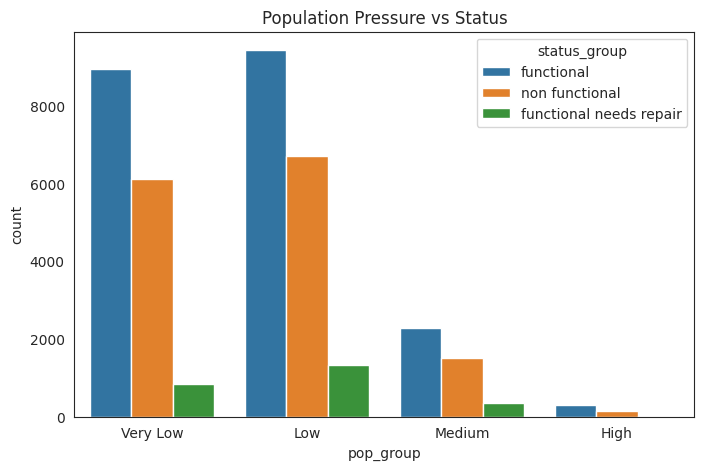

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=final_df,
    x='pop_group',
    hue='status_group'
)

plt.title("Population Pressure vs Status")
plt.show()

In [ ]:
age_status = final_df.groupby('status_group')['construction_age'].mean()
print(age_status)

status_group
functional                 666.326638
functional needs repair    843.667825
non functional             749.747853
Name: construction_age, dtype: float64


In [ ]:
age_extraction = final_df.groupby(['extraction_type_group', 'status_group'])['construction_age'].mean().unstack()
print(age_extraction)

status_group            functional  functional needs repair  non functional
extraction_type_group                                                      
afridev                 920.366667              1107.380952      890.244318
gravity                 439.100636               672.615328      642.164239
india mark ii           622.563536               699.860759      600.192440
india mark iii         1236.863636              2011.000000      272.584906
mono                    945.501848              1254.341085      905.920193
nira/tanira            1379.415237              1510.742590     1130.966539
other                   938.739553               926.276699      823.913378
other handpump          638.488372              1311.800000      803.372093
other motorpump        1707.603774              2011.000000     1977.533333
rope pump               127.508532               600.117647      549.453901
submersible             309.039952               296.359684      494.445129
swn 80      

In [ ]:
final_df.columns

Index(['id', 'amount_tsh', 'date_recorded', 'funder', 'gps_height',
       'installer', 'longitude', 'latitude', 'wpt_name', 'num_private',
       'basin', 'subvillage', 'region', 'region_code', 'district_code', 'lga',
       'ward', 'population', 'public_meeting', 'recorded_by',
       'scheme_management', 'permit', 'construction_year',
       'extraction_type_group', 'management', 'payment_type', 'quality_group',
       'quantity', 'source_type', 'waterpoint_type_group', 'status_group',
       'recorded_year', 'construction_age'],
      dtype='object')

In [ ]:
final_df['date_recorded'] = pd.to_datetime(final_df['date_recorded'], errors='coerce')


final_df['construction_year'] = final_df['construction_year'].replace(0, pd.NA)


final_df['pump_age'] = final_df['date_recorded'].dt.year - final_df['construction_year']


final_df.loc[(final_df['pump_age'] < 0) | (final_df['pump_age'] > 100), 'pump_age'] = pd.NA

In [ ]:
age_extraction = final_df.groupby(['extraction_type_group', 'status_group'])['pump_age'].mean().unstack()
print(age_extraction)

status_group          functional functional needs repair non functional
extraction_type_group                                                  
afridev                 9.253823               12.736842      11.094595
gravity                13.360922               18.093164       22.28605
india mark ii          10.321393               18.769231      11.382114
india mark iii          6.882353                     NaN       8.111111
mono                    9.340278               18.938776      26.172638
nira/tanira            11.873322               16.136646      13.618221
other                  11.405797               15.419643       20.54164
other handpump         10.084746               10.571429      13.480769
other motorpump              1.0                     NaN            3.0
rope pump               4.233577               11.833333      10.067961
submersible             8.873852               11.824885      18.720789
swn 80                 14.686544               16.962963       1

In [ ]:
age_extraction = final_df.groupby(
    ['extraction_type_group', 'status_group']
)['pump_age'].mean().unstack()


age_extraction = age_extraction.round(1)

print(age_extraction)

status_group          functional functional needs repair non functional
extraction_type_group                                                  
afridev                 9.253823               12.736842      11.094595
gravity                13.360922               18.093164       22.28605
india mark ii          10.321393               18.769231      11.382114
india mark iii          6.882353                     NaN       8.111111
mono                    9.340278               18.938776      26.172638
nira/tanira            11.873322               16.136646      13.618221
other                  11.405797               15.419643       20.54164
other handpump         10.084746               10.571429      13.480769
other motorpump              1.0                     NaN            3.0
rope pump               4.233577               11.833333      10.067961
submersible             8.873852               11.824885      18.720789
swn 80                 14.686544               16.962963       1

In [ ]:
age_extraction = final_df.groupby(
    ['extraction_type_group', 'status_group']
)['pump_age'].mean().unstack()


age_extraction = age_extraction.apply(pd.to_numeric, errors='coerce')

**Heatmap: Extraction Methods vs Average Pump Age**

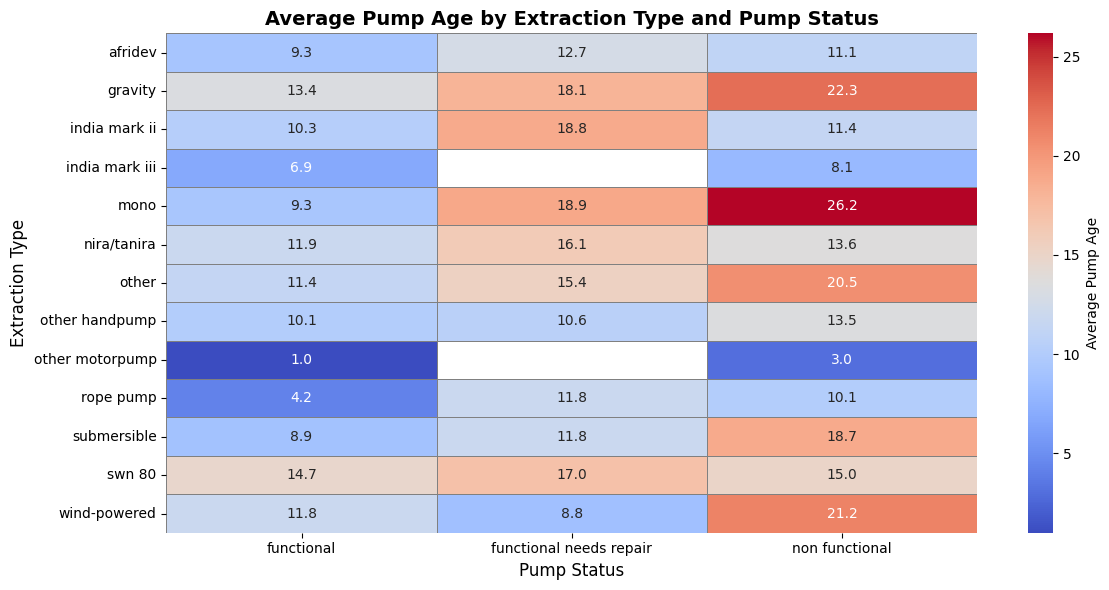

In [ ]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    age_extraction,
    annot=True,
    fmt=".1f",
    cmap="coolwarm",
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Average Pump Age'}
)

plt.title('Average Pump Age by Extraction Type and Pump Status', fontsize=14, weight='bold')
plt.xlabel('Pump Status', fontsize=12)
plt.ylabel('Extraction Type', fontsize=12)

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

**Impact of Pump Age and Population Served on Status**

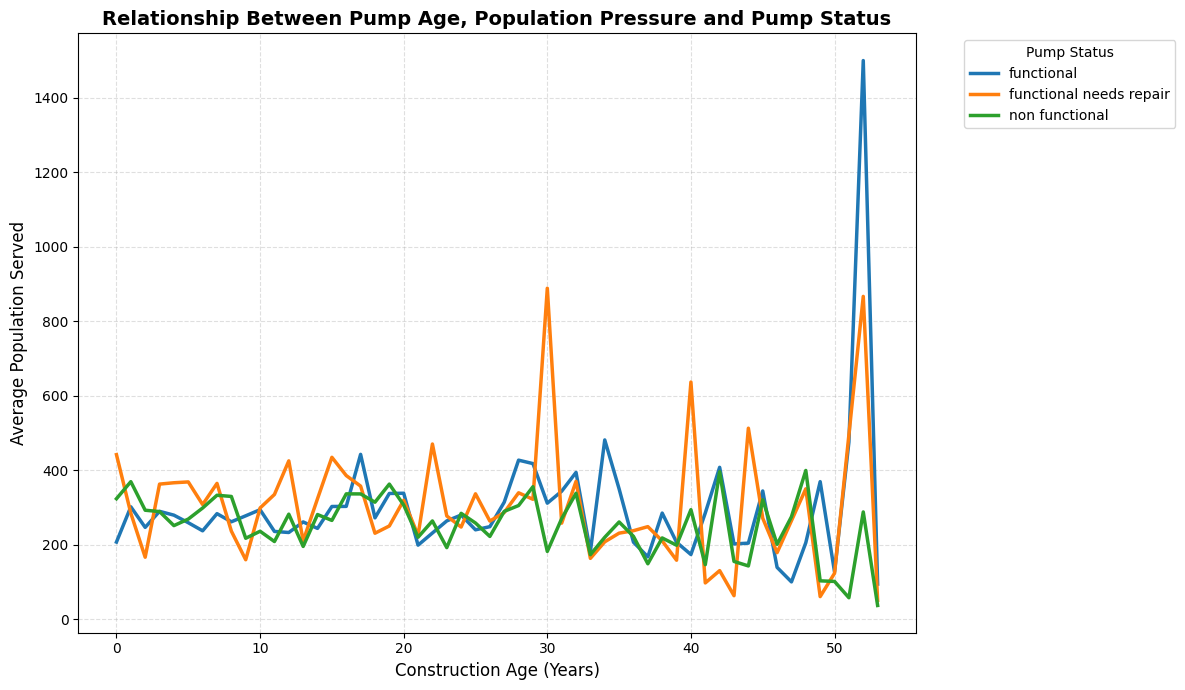

In [ ]:
plt.figure(figsize=(12,7))

df_grouped = final_df.groupby(
    ["pump_age", "status_group"]
)["population"].mean().reset_index()

sns.lineplot(
    data=df_grouped,
    x="pump_age",
    y="population",
    hue="status_group",
    linewidth=2.5
)

# Title and labels (clearer wording)
plt.title("Relationship Between Pump Age, Population Pressure and Pump Status",
          fontsize=14, fontweight="bold")

plt.xlabel("Construction Age (Years)", fontsize=12)
plt.ylabel("Average Population Served", fontsize=12)

# Grid for easier reading
plt.grid(True, linestyle="--", alpha=0.4)

# Better legend placement
plt.legend(title="Pump Status", bbox_to_anchor=(1.05, 1), loc="upper left")



plt.tight_layout()
plt.show()

**Distribution of Pump Status by Management Type**

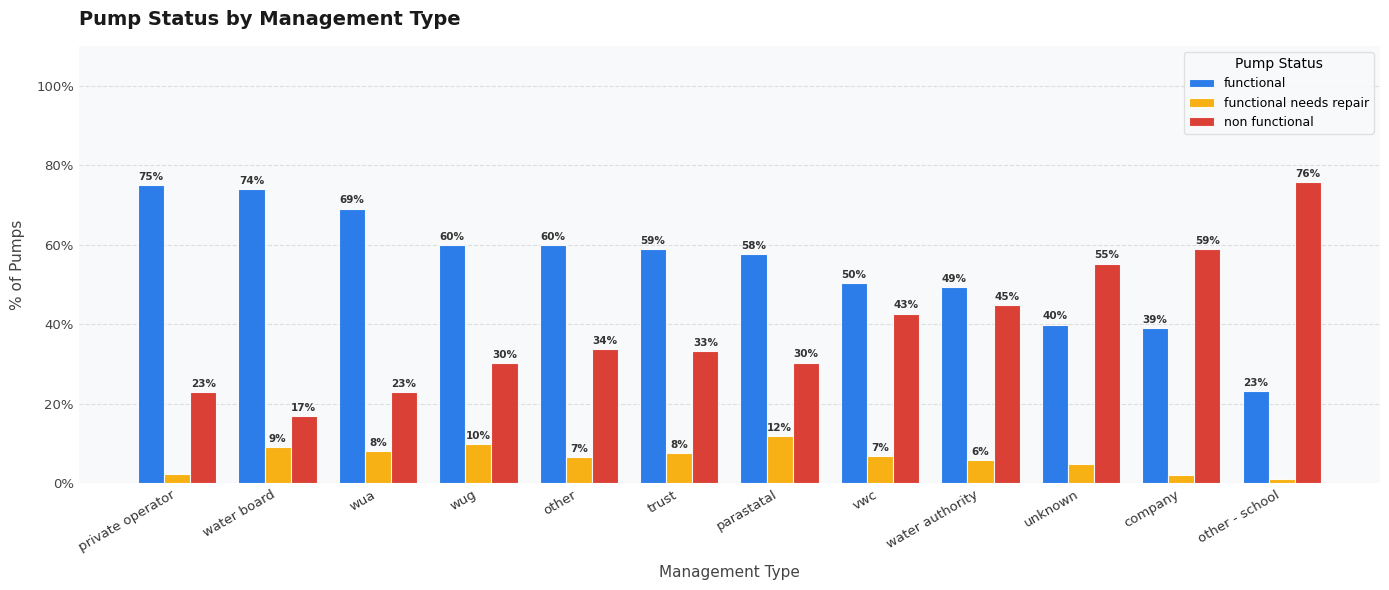

In [ ]:
grouped1 = (
    final_df.groupby(["management", "status_group"])
    .size()
    .reset_index(name="count")
)
total1 = grouped1.groupby("management")["count"].transform("sum")
grouped1["percentage"] = (grouped1["count"] / total1) * 100

pivot1 = grouped1.pivot(index="management", columns="status_group", values="percentage").fillna(0)
pivot1 = pivot1.sort_values("functional", ascending=False)

min_count = final_df.groupby("management").size()
valid = min_count[min_count >= 50].index
pivot1 = pivot1.loc[pivot1.index.isin(valid)]


plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.facecolor": "#F8F9FA",
    "figure.facecolor": "white",
})

fig1, ax1 = plt.subplots(figsize=(14, 6))

colors = {
    "functional": "#1A73E8",
    "functional needs repair": "#F9AB00",
    "non functional": "#D93025"
}

x1 = np.arange(len(pivot1.index))
width = 0.26

for i, col in enumerate(["functional", "functional needs repair", "non functional"]):
    if col in pivot1.columns:
        offset = (i - 1) * width
        bars = ax1.bar(
            x1 + offset, pivot1[col],
            width=width, label=col,
            color=colors[col],
            edgecolor="white",
            linewidth=0.8,
            alpha=0.92,
            zorder=3
        )

        for bar in bars:
            height = bar.get_height()
            if height > 5:
                ax1.text(
                    bar.get_x() + bar.get_width() / 2,
                    height + 0.8,
                    f"{height:.0f}%",
                    ha="center", va="bottom",
                    fontsize=7.5, fontweight="bold",
                    color="#333333"
                )


ax1.set_title("Pump Status by Management Type", fontsize=14, fontweight="bold",
              pad=15, color="#1A1A1A", loc="left")
ax1.set_xlabel("Management Type", fontsize=11, color="#444444", labelpad=8)
ax1.set_ylabel("% of Pumps", fontsize=11, color="#444444", labelpad=8)


ax1.set_xticks(x1)
ax1.set_xticklabels(pivot1.index, rotation=30, ha="right", fontsize=9.5, color="#333333")
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.set_ylim(0, 110)
ax1.tick_params(axis="y", labelsize=9.5, colors="#444444")


ax1.grid(axis="y", linestyle="--", alpha=0.6, color="#CCCCCC", zorder=0)
ax1.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax1.tick_params(axis="both", length=0)


ax1.legend(
    title="Pump Status", fontsize=9, title_fontsize=10,
    frameon=True, framealpha=0.9,
    edgecolor="#DDDDDD", loc="upper right"
)

plt.tight_layout()
plt.savefig("chart1_management_status.png", dpi=150, bbox_inches="tight")
plt.show()